In [1]:
import json
from pathlib import Path

import pandas as pd
import nltk
import spacy

from nltk import RegexpParser
from nltk.wsd import lesk
from nltk.corpus import wordnet as wn
from nltk import CFG
from nltk.parse import ChartParser

import networkx as nx
import matplotlib.pyplot as plt

In [12]:
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

nlp = spacy.load("en_core_web_sm")

OUT = Path("module4_outputs")
OUT.mkdir(exist_ok=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nisan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nisan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nisan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
def load_lines():
    """
    Prefers preprocessed_lines.csv with column 'line' or 'PlayerLine'.
    Falls back to Shakespeare.csv -> PlayerLine.
    """
    if Path("preprocessed_lines.csv").exists():
        df = pd.read_csv("preprocessed_lines.csv", dtype=str, keep_default_na=False)
        if "line" in df.columns:
            lines = df["line"].astype(str).str.strip().tolist()
        elif "PlayerLine" in df.columns:
            lines = df["PlayerLine"].astype(str).str.strip().tolist()
        else:
            raise ValueError("preprocessed_lines.csv must contain 'line' or 'PlayerLine'")
    elif Path("Shakespeare.csv").exists():
        df = pd.read_csv("Shakespeare.csv", dtype=str, keep_default_na=False)
        if "PlayerLine" not in df.columns:
            raise ValueError("Shakespeare.csv must contain 'PlayerLine'")
        lines = df["PlayerLine"].astype(str).str.strip().tolist()
    else:
        # fallback example
        lines = [
            "Barack Obama visited India in 2015.",
            "The cat chased the mouse.",
            "I deposited money in the bank.",
            "The fisherman sat on the river bank."
        ]

    return [x for x in lines if x and x.strip()]

lines = load_lines()

In [4]:
def run_ner(lines):
    rows = []
    for i, line in enumerate(lines):
        doc = nlp(line)
        for ent in doc.ents:
            rows.append({
                "line_id": i,
                "sentence": line,
                "entity": ent.text,
                "label": ent.label_
            })
    return pd.DataFrame(rows)

In [5]:
#lines = lines[:100]
ner_df = run_ner(lines)
ner_df.to_csv(OUT / "ner_results.csv", index=False, encoding="utf-8")

In [6]:
def run_dependency_parse(lines):
    rows = []
    for i, line in enumerate(lines):
        doc = nlp(line)
        for tok in doc:
            if tok.is_space:
                continue
            rows.append({
                "line_id": i,
                "sentence": line,
                "token": tok.text,
                "lemma": tok.lemma_,
                "pos": tok.pos_,
                "tag": tok.tag_,
                "dep": tok.dep_,
                "head": tok.head.text
            })
    return pd.DataFrame(rows)

In [7]:
dep_df = run_dependency_parse(lines)
dep_df.to_csv(OUT / "dependency_parse.csv", index=False, encoding="utf-8")

In [8]:
grammar = r"NP: {<DT>?<JJ.*>*<NN.*>+}"
chunker = RegexpParser(grammar)

In [9]:
def run_np_chunking(lines):
    rows = []
    for i, line in enumerate(lines):
        doc = nlp(line)
        tagged = [(tok.text, tok.tag_) for tok in doc if not tok.is_space]
        tree = chunker.parse(tagged)

        # store full tree string
        rows.append({
            "line_id": i,
            "sentence": line,
            "parse_tree": str(tree)
        })

        # extract noun phrases
        for subtree in tree.subtrees(lambda t: t.label() == "NP"):
            np_text = " ".join(word for word, tag in subtree.leaves())
            rows.append({
                "line_id": i,
                "sentence": line,
                "parse_tree": "",
                "noun_phrase": np_text
            })
    return pd.DataFrame(rows)

In [10]:
np_df = run_np_chunking(lines)
np_df.to_csv(OUT / "noun_phrase_chunks.csv", index=False, encoding="utf-8")

In [11]:
def run_wsd(lines, targets=None):
    """
    targets: list of ambiguous words to test.
    If None, uses a small default list.
    """
    if targets is None:
        targets = ["bank", "light", "sound", "lead", "play"]

    rows = []
    for i, line in enumerate(lines):
        doc = nlp(line)
        tokens = [t.text.lower() for t in doc if not t.is_space]

        for target in targets:
            if target.lower() not in tokens:
                continue

            syn = lesk(tokens, target.lower())
            if syn is None:
                rows.append({
                    "line_id": i,
                    "sentence": line,
                    "word": target,
                    "chosen_synset": None,
                    "definition": None
                })
            else:
                rows.append({
                    "line_id": i,
                    "sentence": line,
                    "word": target,
                    "chosen_synset": syn.name(),
                    "definition": syn.definition()
                })
    return pd.DataFrame(rows)

In [12]:
wsd_df = run_wsd(lines)
wsd_df.to_csv(OUT / "wsd_results.csv", index=False, encoding="utf-8")

In [13]:
print("NER rows:", len(ner_df))
print("Dependency rows:", len(dep_df))
print("Chunk rows:", len(np_df))
print("WSD rows:", len(wsd_df))
print("Saved to:", OUT.resolve())

NER rows: 30173
Dependency rows: 1007075
Chunk rows: 301476
WSD rows: 876
Saved to: C:\Users\nisan\Desktop\code\nlp\module4_outputs


In [6]:
grammar = CFG.fromstring("""
S -> NP VP
NP -> DT NN
VP -> V NP
DT -> 'the'
NN -> 'king' | 'palace'
V -> 'enters'
""")

parser = ChartParser(grammar)

In [7]:
sentence = "the king enters the palace"
tokens = sentence.split()

In [ ]:
for tree in parser.parse(tokens):
    print(tree)
    tree.pretty_print()
    tree.draw()

(S (NP (DT the) (NN king)) (VP (V enters) (NP (DT the) (NN palace))))
               S                  
      _________|_____              
     |               VP           
     |          _____|___          
     NP        |         NP       
  ___|___      |      ___|____     
 DT      NN    V     DT       NN  
 |       |     |     |        |    
the     king enters the     palace



In [2]:
def tree_to_graph(tree):
    G = nx.DiGraph()
    pos = {}
    node_id = 0

    def add_nodes(t, parent=None, depth=0, x=0):
        nonlocal node_id
        current_id = node_id
        G.add_node(current_id, label=t.label() if hasattr(t, 'label') else str(t))
        pos[current_id] = (x, -depth)
        node_id += 1

        if parent is not None:
            G.add_edge(parent, current_id)

        if hasattr(t, '__iter__') and not isinstance(t, str):
            width = len(t)
            for i, child in enumerate(t):
                add_nodes(child, current_id, depth+1, x + i - width/2)

    add_nodes(tree)
    return G, pos

In [3]:
def draw_tree_walker(tree):
    G, pos = tree_to_graph(tree)
    labels = nx.get_node_attributes(G, 'label')

    plt.figure(figsize=(10,6))
    nx.draw(G, pos, labels=labels, with_labels=True, node_size=2000, font_size=10)
    plt.title("Walker-style Tree Layout")
    plt.show()

(S (NP (DT the) (NN king)) (VP (V enters) (NP (DT the) (NN palace))))
               S                  
      _________|_____              
     |               VP           
     |          _____|___          
     NP        |         NP       
  ___|___      |      ___|____     
 DT      NN    V     DT       NN  
 |       |     |     |        |    
the     king enters the     palace



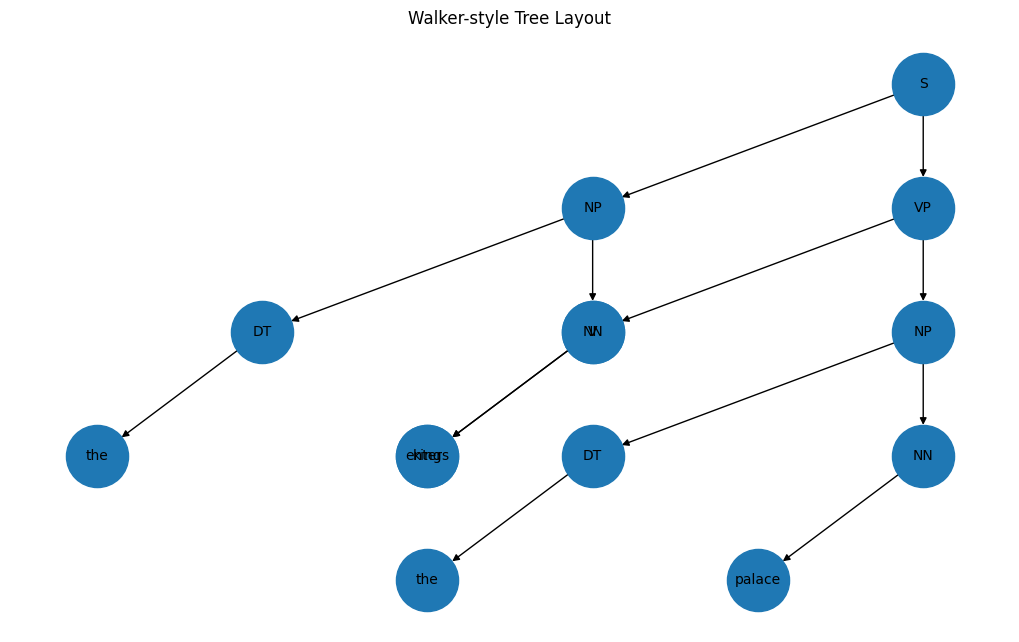

In [8]:
for tree in parser.parse(tokens):
    print(tree)
    tree.pretty_print()
    draw_tree_walker(tree)

In [9]:
def draw_dependency_graph(sentence):
    import networkx as nx
    import matplotlib.pyplot as plt

    doc = nlp(sentence)

    G = nx.DiGraph()

    for token in doc:
        if token.is_space:
            continue

        G.add_node(token.text)

        if token.head != token:
            G.add_edge(token.head.text, token.text, label=token.dep_)

    pos = nx.spring_layout(G)

    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}

    plt.figure(figsize=(10,6))
    nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10, arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title("Dependency Parse (Arrow Diagram)")
    plt.show()

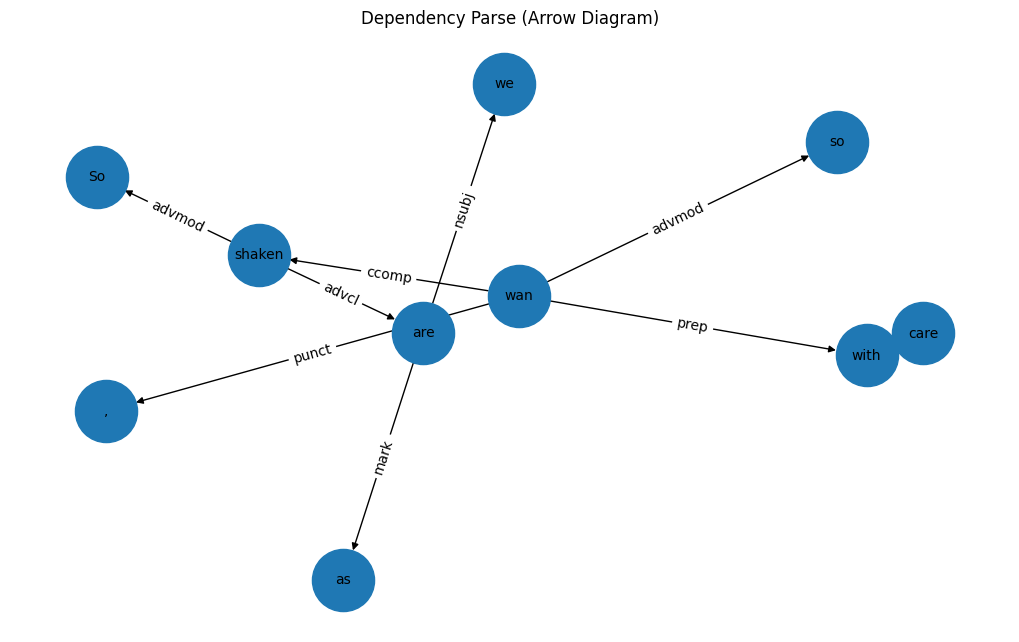

In [13]:
draw_dependency_graph("So shaken as we are, so wan with care")